PyTorch 로지스틱 회귀 예측

In [1]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt 

torch.manual_seed(2)

In [2]:
z = torch.arange(-100, 100, 0.1).view(-1, 1)
print("The tensor: ", z)

The tensor:  tensor([[-100.0000],
        [ -99.9000],
        [ -99.8000],
        ...,
        [  99.7000],
        [  99.8000],
        [  99.9000]])


Text(0, 0.5, 'yhat')

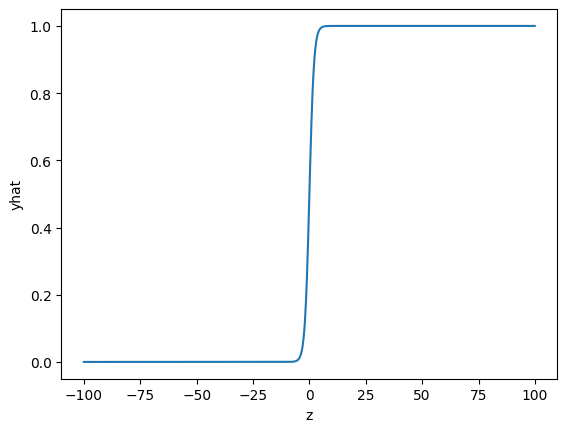

In [3]:
# nn.Sigmoid()
sig = nn.Sigmoid()
yhat = sig(z)

plt.plot(z.numpy(), yhat.numpy())
plt.xlabel('z')
plt.ylabel('yhat')

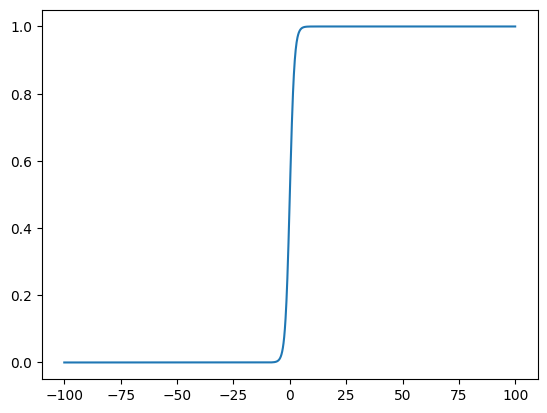

In [4]:
# torch.sigmoid()
yhat = torch.sigmoid(z)
plt.plot(z.numpy(), yhat.numpy())

In [24]:
# 선형회귀 + 시그모이드 합성모델
model = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid())

# x = [[1]], X = [[1], [100]]
x = torch.tensor([[1.0]])
X = torch.tensor([[1.0], [100]])
print('x = ', x)
print('X = ', X)
print("list(model.parameters()):\n ", list(model.parameters()))
print("\nmodel.state_dict():\n ", model.state_dict())

x =  tensor([[1.]])
X =  tensor([[  1.],
        [100.]])
list(model.parameters()):
  [Parameter containing:
tensor([[-0.2199]], requires_grad=True), Parameter containing:
tensor([0.8177], requires_grad=True)]

model.state_dict():
  OrderedDict({'0.weight': tensor([[-0.2199]]), '0.bias': tensor([0.8177])})


In [25]:
yhat = model(x)
yhat

tensor([[0.6452]], grad_fn=<SigmoidBackward0>)

In [26]:
yhat = model(X)
yhat

tensor([[6.4515e-01],
        [6.3835e-10]], grad_fn=<SigmoidBackward0>)

In [27]:
model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

# x = [[1, 1]], X = [[1, 1], [1, 2], [1, 3]]
x = torch.tensor([[1.0, 1.0]])
X = torch.tensor([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
print('x = ', x)
print('X = ', X)
print("list(model.parameters()):\n ", list(model.parameters()))
print("\nmodel.state_dict():\n ", model.state_dict())

x =  tensor([[1., 1.]])
X =  tensor([[1., 1.],
        [1., 2.],
        [1., 3.]])
list(model.parameters()):
  [Parameter containing:
tensor([[0.0472, 0.2932]], requires_grad=True), Parameter containing:
tensor([0.2992], requires_grad=True)]

model.state_dict():
  OrderedDict({'0.weight': tensor([[0.0472, 0.2932]]), '0.bias': tensor([0.2992])})


In [28]:
yhat = model(x)
yhat

tensor([[0.6547]], grad_fn=<SigmoidBackward0>)

In [29]:
yhat = model(X)
yhat

tensor([[0.6547],
        [0.7177],
        [0.7731]], grad_fn=<SigmoidBackward0>)

In [30]:
# 커스텀 로지스틱 회귀 클래스 구현
class logistic_regression(nn.Module):
    
    # Constructor
    def __init__(self, n_inputs):
        super(logistic_regression, self).__init__()
        self.linear = nn.Linear(n_inputs, 1)
    
    # Prediction
    def forward(self, x):
        yhat = torch.sigmoid(self.linear(x))
        return yhat

In [31]:
model = logistic_regression(1)

# x = [[1]], X = [[-100], [0], [100]]
x = torch.tensor([[1.0]])
X = torch.tensor([[-100], [0], [100.0]])
print('x = ', x)
print('X = ', X)
print("list(model.parameters()):\n ", list(model.parameters()))
print("\nmodel.state_dict():\n ", model.state_dict())

x =  tensor([[1.]])
X =  tensor([[-100.],
        [   0.],
        [ 100.]])
list(model.parameters()):
  [Parameter containing:
tensor([[-0.5899]], requires_grad=True), Parameter containing:
tensor([-0.3844], requires_grad=True)]

model.state_dict():
  OrderedDict({'linear.weight': tensor([[-0.5899]]), 'linear.bias': tensor([-0.3844])})


In [34]:
yhat = model(x)
yhat

tensor([[0.2740]], grad_fn=<SigmoidBackward0>)

In [35]:
yhat = model(X)
yhat

tensor([[1.0000e+00],
        [4.0506e-01],
        [1.6317e-26]], grad_fn=<SigmoidBackward0>)

In [36]:
model = logistic_regression(2)

x = torch.tensor([[1.0, 2.0]])
X = torch.tensor([[100, -100], [0.0, 0.0], [-100, 100]])
print('x = ', x)
print('X = ', X)

x =  tensor([[1., 2.]])
X =  tensor([[ 100., -100.],
        [   0.,    0.],
        [-100.,  100.]])


In [37]:
yhat = model(x)
yhat

tensor([[0.3201]], grad_fn=<SigmoidBackward0>)

In [38]:
yhat = model(X)
yhat

tensor([[1.0000],
        [0.4880],
        [0.0000]], grad_fn=<SigmoidBackward0>)